# Customer Churn Data Preparation & Exploratory Data Analysis

## Author : Ayisha Mariyam

This project performs **data preparation, feature engineering, and exploratory data analysis (EDA)** on the Telecom Customer Churn dataset.

---

## 🎯 Objective

Prepare customer data for modeling using:

• Data cleaning  
• Handling missing values  
• Feature engineering  
• Exploratory data analysis  

---

## 🧠 Skills Demonstrated

- Data cleaning
- Handling inconsistent data types
- Feature engineering
- Encoding categorical variables
- Correlation analysis
- Data visualization using Seaborn

---

## 📂 Dataset

**Telecom Customer Churn Dataset**

The dataset contains customer details such as:

- Demographics
- Service subscriptions
- Billing information
- Contract details
- Churn status

Rows: ~7000 customers

In [1]:
# Import core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath("E:\\VS CODE\\The Skybrisk Internship 3 months\\Month 2\\src"))

# Visualization style
sns.set_style("whitegrid")
sns.set_palette("dark")

print("Core libraries loaded")

Core libraries loaded


In [2]:
import sys
print(sys.path)

sys.path.append(os.path.abspath(os.getcwd() + "/.."))

['c:\\Users\\HP\\AppData\\Local\\Python\\pythoncore-3.14-64\\python314.zip', 'c:\\Users\\HP\\AppData\\Local\\Python\\pythoncore-3.14-64\\DLLs', 'c:\\Users\\HP\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib', 'c:\\Users\\HP\\AppData\\Local\\Python\\pythoncore-3.14-64', '', 'C:\\Users\\HP\\AppData\\Roaming\\Python\\Python314\\site-packages', 'c:\\Users\\HP\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages', 'E:\\VS CODE\\The Skybrisk Internship 3 months\\Month 2\\src']


In [3]:
# Import project modules from src folder

from src.data_cleaning import (
    load_data,
    basic_cleaning,
    clean_total_charges,
    handle_missing_values
)

from src.feature_engineering import (
    create_tenure_group,
    average_monthly_spend,
    binary_encoding,
    encode_gender,
    one_hot_encoding
)

from src.visualization import (
    churn_countplot,
    contract_vs_churn,
    monthlycharges_boxplot,
    tenure_boxplot,
    correlation_heatmap,
    pairplot_visual
)

from src.utils import (
    dataset_overview,
    check_missing_values,
    save_clean_data,
    unique_values
)

print("Project modules imported successfully")

Project modules imported successfully


# Load Dataset

The dataset is stored in:

data/raw/telco_customer_churn.csv


We load the dataset using our reusable function from `data_cleaning.py`.


In [4]:
df = load_data("../data/raw/telco_customer_churn.csv")

df.head()

Dataset Loaded Successfully


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#  Data Understanding

Before cleaning the dataset we need to understand:

• Data types  
• Column structure  
• Summary statistics  

In [5]:
dataset_overview(df)


DATASET INFO

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str 

## Dataset Shape

In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


## Unique Values per Column

In [7]:
unique_values(df)


Column: customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

Column: gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Column: SeniorCitizen
[0 1]

Column: Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

Column: PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

Column: I

#  Missing Values Analysis

Check for missing values and unusual data.

In [8]:
check_missing_values(df)


MISSING VALUES

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Identify Strange Values

The **TotalCharges** column sometimes contains blank spaces instead of numeric values.

In [9]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


#  Data Cleaning

Cleaning steps:

1. Basic column cleaning
2. Fix TotalCharges datatype
3. Handle missing values

In [10]:
df = basic_cleaning(df)

df = clean_total_charges(df)

df = handle_missing_values(df)

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

#  Feature Engineering

New features created:

• TenureGroup  
• AvgMonthlySpend  

Encoding:

• Binary encoding  
• Gender encoding  
• One-hot encoding

## Create Tenure Groups

In [11]:
df = create_tenure_group(df)

df[["tenure", "TenureGroup"]].head()

,tenure,TenureGroup
0,1,0-12
1,34,25-48
2,2,0-12
3,45,25-48
4,2,0-12


## Calculate Average Monthly Spend

In [12]:
df = average_monthly_spend(df)

df[["TotalCharges", "tenure", "AvgMonthlySpend"]].head()

,TotalCharges,tenure,AvgMonthlySpend
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


#  Exploratory Data Analysis

We visualize churn patterns using several plots:

• Churn distribution  
• Contract vs churn  
• Monthly charges vs churn  
• Tenure vs churn  
• Correlation heatmap  

## Churn Distribution

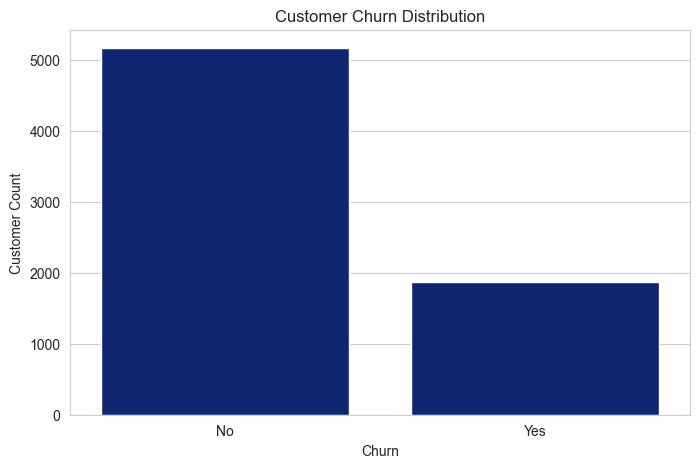

In [13]:
churn_countplot(df)

## Contract vs Churn

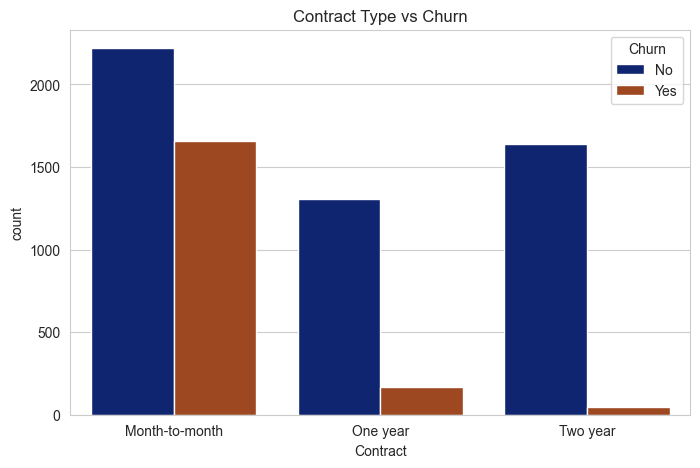

In [14]:
contract_vs_churn(df)

## Monthly Charges vs Churn

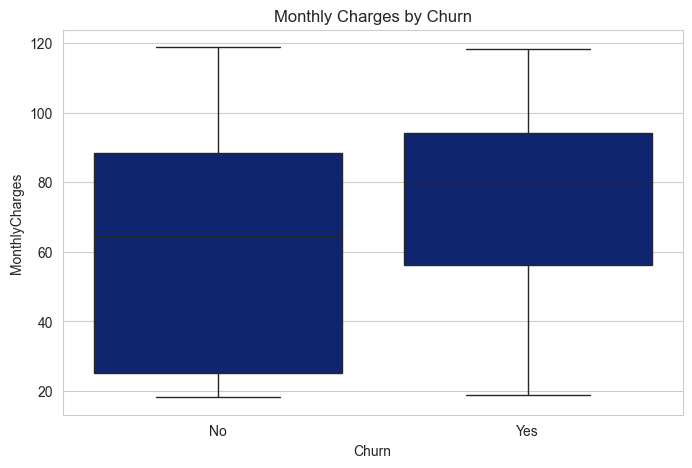

In [15]:
monthlycharges_boxplot(df)

## Tenure vs Churn

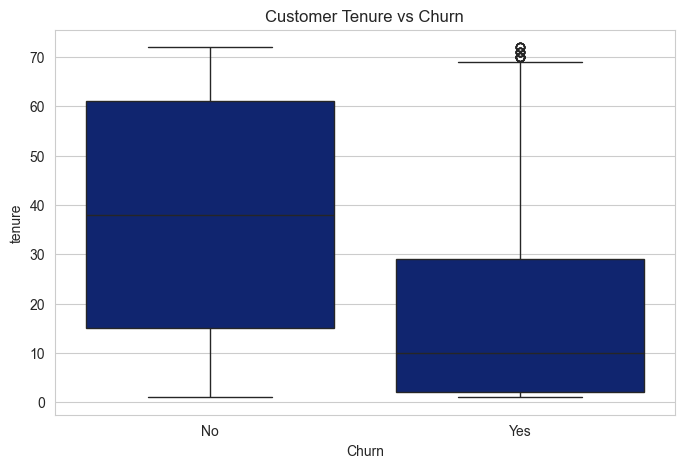

In [16]:
tenure_boxplot(df)

## Correlation Heatmap

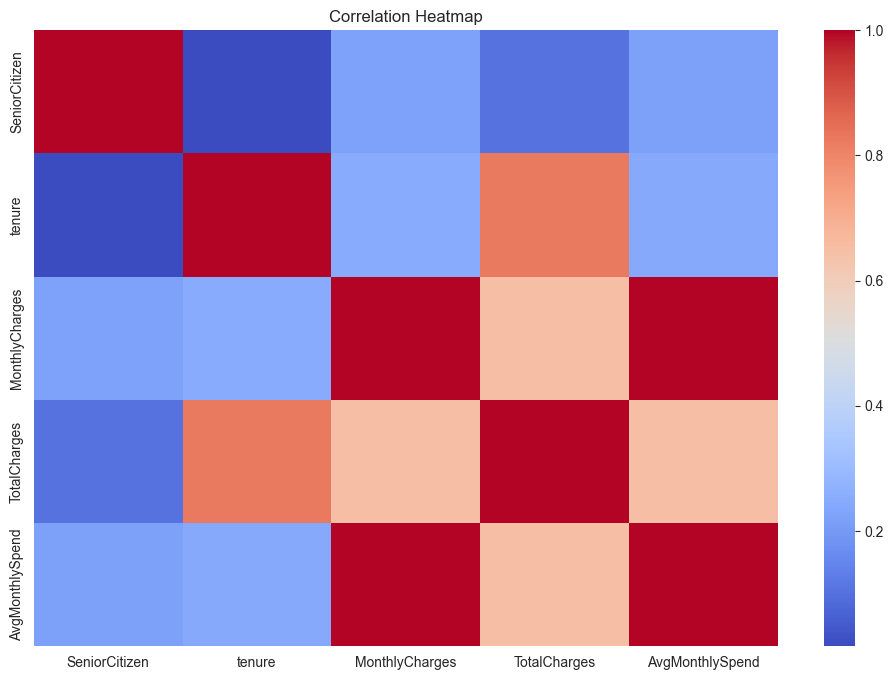

In [17]:
correlation_heatmap(df)

## Pairplot Analysis

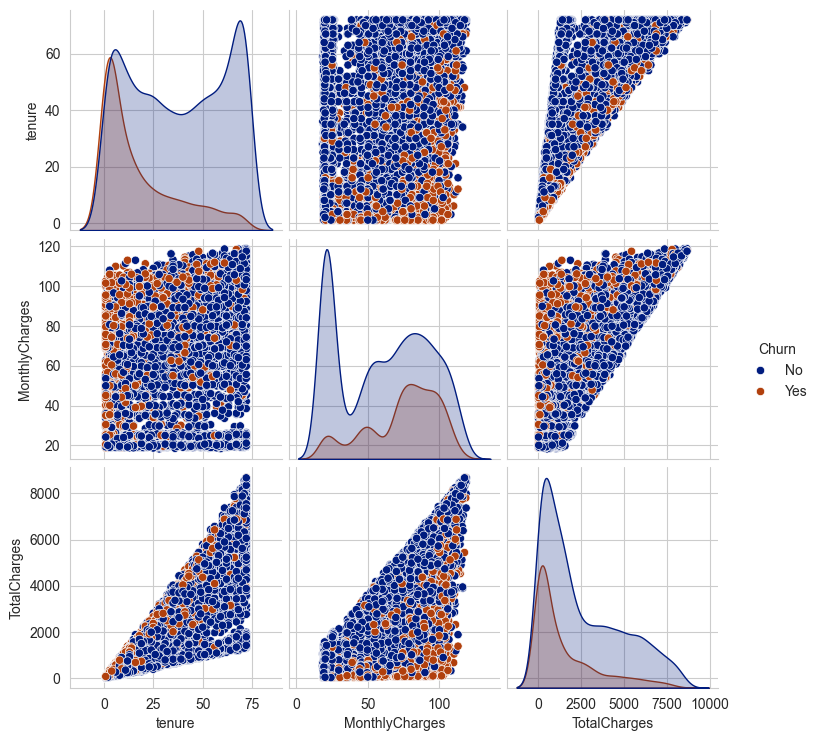

In [18]:
pairplot_visual(df)

# Encoding 

## Binary encoding
## Gender Encoding
## One Hot Encoding

In [19]:
df = binary_encoding(df)

df = encode_gender(df)

df = one_hot_encoding(df)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Churn,TenureGroup,AvgMonthlySpend,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,No phone service,No,Yes,...,0,0-12,29.850000,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,No,Yes,No,...,0,25-48,55.573529,True,False,False,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,No,Yes,Yes,...,1,0-12,54.075000,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,No phone service,Yes,No,...,0,25-48,40.905556,True,False,False,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,No,No,No,...,1,0-12,75.825000,False,False,True,False,False,True,False


#  Business Insights

Based on the analysis we identified the following insights.

In [20]:
insights = [
    "Customers with month-to-month contracts have the highest churn rate.",
    "Customers with higher monthly charges tend to churn more frequently.",
    "Customers with shorter tenure are more likely to churn.",
    "Fiber optic internet users show slightly higher churn behaviour.",
    "Paperless billing users tend to churn more frequently."
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. Customers with month-to-month contracts have the highest churn rate.
2. Customers with higher monthly charges tend to churn more frequently.
3. Customers with shorter tenure are more likely to churn.
4. Fiber optic internet users show slightly higher churn behaviour.
5. Paperless billing users tend to churn more frequently.


#  Export Cleaned Dataset

The cleaned dataset will be saved for future modeling tasks.

In [21]:
save_clean_data(df, "../data/processed/telecom_churn_cleaned.csv")


Cleaned dataset saved to: ../data/processed/telecom_churn_cleaned.csv


# Final Dataset Preview

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Churn,TenureGroup,AvgMonthlySpend,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,No phone service,No,Yes,...,0,0-12,29.850000,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,No,Yes,No,...,0,25-48,55.573529,True,False,False,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,No,Yes,Yes,...,1,0-12,54.075000,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,No phone service,Yes,No,...,0,25-48,40.905556,True,False,False,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,No,No,No,...,1,0-12,75.825000,False,False,True,False,False,True,False


# Conclusion

In this project we successfully prepared the Telecom Customer Churn dataset for analysis and modeling.

### Key Steps Completed

✔ Data understanding  
✔ Data cleaning  
✔ Feature engineering  
✔ Encoding categorical variables  
✔ Exploratory data analysis  
✔ Business insight extraction  

The cleaned dataset can now be used for **machine learning models such as churn prediction**.